Assignment no 10.Implement a basic Federated Reinforcement Learning example where two or more agents learn
to reach a goal in a small grid game. Each agent learns locally using Q-learning and sends its
learned values to a server, which averages them and sends the updated model back to the agents
to improve learning together.

**Install Libraries**

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt


**Create Grid Environment**

In [2]:
class GridWorld:
    def __init__(self, size=4):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.get_state_index(self.state)

    def get_state_index(self, state):
        return state[0] * self.size + state[1]

    def step(self, action):
        x, y = self.state

        if action == 0:  # Up
            x = max(0, x - 1)
        elif action == 1:  # Down
            x = min(self.size - 1, x + 1)
        elif action == 2:  # Left
            y = max(0, y - 1)
        elif action == 3:  # Right
            y = min(self.size - 1, y + 1)

        self.state = (x, y)

        if self.state == self.goal:
            return self.get_state_index(self.state), 10, True
        else:
            return self.get_state_index(self.state), -1, False


**Define Q-Learning Agent**

In [3]:
class Agent:
    def __init__(self, state_size, action_size, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.q_table = np.zeros((state_size, action_size))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, 3)
        return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state):
        best_next = np.max(self.q_table[next_state])
        self.q_table[state][action] += self.alpha * (
            reward + self.gamma * best_next - self.q_table[state][action]
        )


**Federated Server (Averaging)**

In [4]:
class Server:
    def aggregate(self, q_tables):
        return np.mean(q_tables, axis=0)


**Federated Training Function**

In [5]:
def federated_training(num_agents=3, episodes=100, rounds=10):

    state_size = 16
    action_size = 4

    agents = [Agent(state_size, action_size) for _ in range(num_agents)]
    server = Server()

    reward_history = []

    for r in range(rounds):
        print(f"Federated Round {r+1}")

        local_q_tables = []
        round_rewards = []

        for agent in agents:
            env = GridWorld()
            total_reward = 0

            for ep in range(episodes):
                state = env.reset()
                done = False

                while not done:
                    action = agent.choose_action(state)
                    next_state, reward, done = env.step(action)

                    agent.update(state, action, reward, next_state)
                    state = next_state
                    total_reward += reward

            local_q_tables.append(agent.q_table)
            round_rewards.append(total_reward)

        # Server aggregation
        global_q = server.aggregate(local_q_tables)

        # Send global model back to agents
        for agent in agents:
            agent.q_table = np.copy(global_q)

        avg_reward = np.mean(round_rewards)
        reward_history.append(avg_reward)

        print("Average Reward:", avg_reward)

    return global_q, reward_history


**Run Training**

In [6]:
global_q_table, rewards = federated_training(
    num_agents=3,
    episodes=100,
    rounds=15
)

print("\nFinal Global Q-Table:")
print(global_q_table)


Federated Round 1
Average Reward: 117.66666666666667
Federated Round 2
Average Reward: 349.3333333333333
Federated Round 3
Average Reward: 380.0
Federated Round 4
Average Reward: 365.3333333333333
Federated Round 5
Average Reward: 384.6666666666667
Federated Round 6
Average Reward: 363.6666666666667
Federated Round 7
Average Reward: 360.0
Federated Round 8
Average Reward: 348.0
Federated Round 9
Average Reward: 360.6666666666667
Federated Round 10
Average Reward: 345.3333333333333
Federated Round 11
Average Reward: 381.6666666666667
Federated Round 12
Average Reward: 379.0
Federated Round 13
Average Reward: 358.6666666666667
Federated Round 14
Average Reward: 386.0
Federated Round 15
Average Reward: 370.3333333333333

Final Global Q-Table:
[[ 0.62836601  1.80924031  0.62824716  1.8098    ]
 [ 1.80802196  3.122       0.62750847  3.12007845]
 [ 0.9948159   4.57999881  0.27480547  0.4810274 ]
 [-0.02913752  4.91542308 -0.18969263  0.11095056]
 [-0.26019174  0.19069174  0.47215128  3.12199

**Plot Learning Curve**

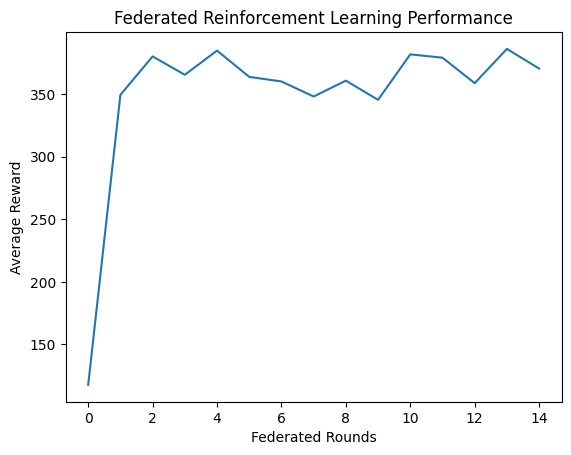

In [7]:
plt.plot(rewards)
plt.xlabel("Federated Rounds")
plt.ylabel("Average Reward")
plt.title("Federated Reinforcement Learning Performance")
plt.show()
